In [69]:
import pandas as pd
import numpy as np
import re
import pickle
from nltk.probability import FreqDist
import spacy
import matplotlib.pyplot as plt
from nltk.draw.dispersion import dispersion_plot
from nltk.text import Text
from wordcloud import WordCloud

Pobranie danych z hugging face

In [70]:
#wczytanie pliku wikipedia_dump
df = pd.read_parquet("train-00000-of-00006.parquet")
print(df.head())

  id                                        url        title  \
0  2          https://pl.wikipedia.org/wiki/AWK          AWK   
1  4  https://pl.wikipedia.org/wiki/Alergologia  Alergologia   
2  6        https://pl.wikipedia.org/wiki/ASCII        ASCII   
3  7         https://pl.wikipedia.org/wiki/Atom         Atom   
4  8     https://pl.wikipedia.org/wiki/Aksjomat     Aksjomat   

                                                text  
0  AWK – interpretowany język programowania, któr...  
1  Alergologia – dziedzina medycyny zajmująca się...  
2  ASCII (czyt. aski, skrót od ang. American Stan...  
3  Atom – podstawowy składnik materii. Składa się...  
4  Aksjomat, postulat, pewnik (gr.  axíōma, godno...  


Losowanie artykułów i czyszczenie danych

In [71]:
#wylosowanie 900 artykułów
sample_df = df.sample(n=900, random_state=1) 
texts = sample_df['text'].tolist()

#czyszczenie
cut_after = ["Zobacz też", "Linki zewnętrzne", "Bibliografia", "Literatura", "Uwagi", "Przypisy"] 
#jeszcze nie usuwamy wielkiej litery zeby zmniejszyc szanse ucięcia artykułu w złym miejscu

clean_texts = []
for text in texts:
    cut_pos = len(text)  #default

    for phrase in cut_after:
        pos = text.find(phrase)
        if pos != -1 and pos < cut_pos:
            cut_pos = pos  #find first occurence

    clean_texts.append(text[:cut_pos].strip())

clean_texts = [text.replace('\n', ' ').lower() for text in clean_texts]
print(clean_texts[:10])

['łajski – wieś w polsce położona w województwie mazowieckim, w powiecie legionowskim, w gminie wieliszew.  w latach 1954-1961 wieś należała i była siedzibą władz gromady łajski, po jej zniesieniu w gromadzie skrzeszew. w latach 1975–1998 miejscowość administracyjnie należała do województwa warszawskiego.  położenie miejscowości  łajski położone są w okolicy kotliny warszawskiej. są to tereny gęsto zalesione, gdzie na północy ciągną się lasy pomiechowskie, a w jej południowo-wschodniej części zachowały się pozostałości puszczy nieporęckiej.  krajobraz jest równinny lekko pofałdowany, okoliczne wzniesienia i pagórki osiągają 75 – 85 m n.p.m.  wieś liczy sobie około 1300 mieszkańców. łajski leżą w bezpośredniej bliskości legionowa, w odległości 20 km od centrum warszawy, przy szlakach komunikacyjnych łączących warszawę z gdańskiem (linia kolejowa) i pojezierzem mazurskim (droga krajowa nr 61). mniej niż 7 km dzieli wieś od zalewu zegrzyńskiego, miejsca letniskowego wypoczynku mieszkańców

Kategoryzacja

In [ ]:
#podzial na krótkie, średnie i długie artykuły

short = []
medium = []
long = []

for text in clean_texts:
    length = len(text)
    if length < 1000:
        continue  #pomijamy bardzo krótkie (mało informatywne)
    elif 1000 <= length <= 2000:
        short.append(text)
    elif 2001 <= length <= 4000:
        medium.append(text)
    else:
        long.append(text)

print(f"Number of short articles: {len(short)}")
print(f"Number of medium articles: {len(medium)}")
print(f"Number of long articles: {len(long)}")

#usunięcie najdłuższego artykułu (outlier) - wynik analizy statystycznej
lengths = [len(text) for text in long[:100]]

#indeks najdłuższego artykułu
outlier_idx = np.argmax(lengths)
long = long[:outlier_idx]+long[outlier_idx+1:101]

con_sho, con_med, con_lon = short[:100], medium[:100], long
train = con_sho + con_med + con_lon
print(f'\nTrain set length: {len(train)}')

Number of short articles: 153
Number of medium articles: 126
Number of long articles: 108

Train set length: 300


In [73]:
#zapis do pliku w celu przygotowania pytań

#zawijanie tesktu do width dla łatwiejszego czytania
def wrap_text(text, width=100):
    return '\n'.join(text[i:i+width] for i in range(0, len(text), width)) 

#zapis
with open("train.txt", "w", encoding="utf-8") as f:
    for i, text in enumerate(train, start=1):
        f.write(f"{i}!!!\n") #znacznik
        wrapped = wrap_text(text, width=110)
        f.write(wrapped + "\n\n")

In [74]:
#wczytujemy ręcznie przygotowane pytania
with open('ques_train.txt', 'r') as file:
    qna_train = file.readlines()
qna_train = [q.replace('\n','').lower() for q in qna_train if q.replace('\n','') !='']

#sprawdzenie zbilansowania zbiorów (po numerach artykułów 0-100 krótkie, 100-200 średnie, 200-300 długie)
lab_qna = [int(qna_train[i]) for i in range(len(qna_train)) if i%3==0] 

print(f'Short: {len([i for i in lab_qna if int(i) < 100])}')
print(f'Medium: {len([i for i in lab_qna if int(i) >=100 and int(i)<200])}')
print(f'Long: {len([i for i in lab_qna if int(i) >=200])}\n')

#podział na pytania/odpowiedzi
ques = [qna_train[i] for i in range(len(qna_train)) if i%3==1]
ans = [qna_train[i] for i in range(len(qna_train)) if i%3==2]

ques_sho, ques_med, ques_lon = ques[:60], ques[60:120], ques[120:]
ans_sho, ans_med, ans_lon = ans[:60], ans[60:120], ans[120:]

Short: 60
Medium: 60
Long: 60



In [75]:
#sprawdz czy każda odpowiedz znajduje sie w artykułach
sho_t = []
sho_f = []
con_sho_all = ''
for t in con_sho:
    con_sho_all +=t

for ans in ans_sho:
    re.escape(ans) 
    matches = re.findall(re.escape(ans), con_sho_all)
    #re.escape zabiezpiecz str przed interpretacją jako regex
    if matches:
        sho_t.append(ans)
    else:
        sho_f.append(ans)

print(len(sho_t), len(sho_f))

60 0


In [76]:
med_t = []
med_f = []
con_med_all = ''
for t in con_med:
    con_med_all +=t

for ans in ans_med:
    re.escape(ans) 
    matches = re.findall(re.escape(ans), con_med_all)
    #re.escape zabiezpiecz str przed interpretacją jako regex
    if matches:
        med_t.append(ans)
    else:
        med_f.append(ans)

print(len(med_t), len(med_f))

60 0


In [77]:
lon_t = []
lon_f = []
con_lon_all = ''
for t in con_lon:
    con_lon_all +=t

for ans in ans_lon:
    re.escape(ans) 
    matches = re.findall(re.escape(ans), con_lon_all)
    #re.escape zabiezpiecz str przed interpretacją jako regex
    if matches:
        lon_t.append(ans)
    else:
        lon_f.append(ans)

print(len(lon_t), len(lon_f))

60 0


In [ ]:
#zapis w celu werifikacji (było dużo pracy z manualnym poprawianiem pytań ze względu na formatowanie)
with open("con_sho_all.txt", "w", encoding="utf-8") as f:
    f.write(con_sho_all)
#zapis
with open("con_med_all.txt", "w", encoding="utf-8") as f:
    f.write(con_med_all)
#zapis
with open("con_lon_all.txt", "w", encoding="utf-8") as f:
    f.write(con_lon_all)

In [79]:
#zapis do ogórka

with open("train_sho.pkl", "wb") as f:
    pickle.dump((short[:100]), f)
with open("train_med.pkl", "wb") as f:
    pickle.dump((medium[:100]), f)
with open("train_long.pkl", "wb") as f:
    pickle.dump((long), f)

with open("ques_sho.pkl", "wb") as f:
    pickle.dump((ques_sho), f)
with open("ques_med.pkl", "wb") as f:
    pickle.dump((ques_med), f)
with open("ques_lon.pkl", "wb") as f:
    pickle.dump((ques_lon), f)

with open("ans_sho.pkl", "wb") as f:
    pickle.dump((ans_sho), f)
with open("ans_med.pkl", "wb") as f:
    pickle.dump((ans_med), f)
with open("ans_lon.pkl", "wb") as f:
    pickle.dump((ans_lon), f)

Statystyka

In [80]:
nlp = spacy.load("pl_core_news_md")

In [81]:
#freq dla pytań i artykułów
ques = ques_lon + ques_med + ques_sho
ques_str = nlp(" ".join([q.lower() for q in ques]))

ques_tok = [t.text for t in ques_str if t.is_alpha and not t.is_stop]
fques = FreqDist(ques_tok)

con = long[:100] + medium[:100] + short[:100]
con_tok = []
for c in con:
    doc = nlp(c.lower())
    con_tok.extend([t.text for t in doc if t.is_alpha and not t.is_stop])

fcon = FreqDist(con_tok)

Pytania:
Ilość: 180
Średnia długość: 9.21
Mediana długości: 9.0
Min długość: 4
Maks długość: 17


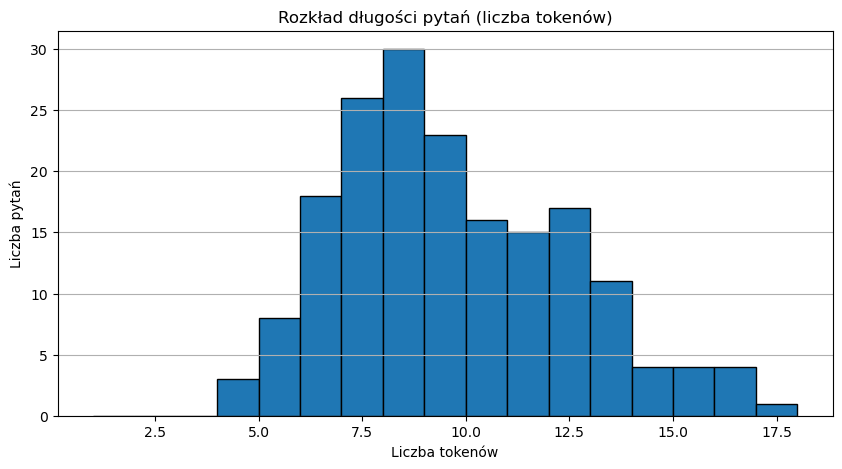

Artykuły:
Ilość: 300
Średnia długość: 845.70
Mediana długości: 466.5
Min długość: 156
Maks długość: 8513


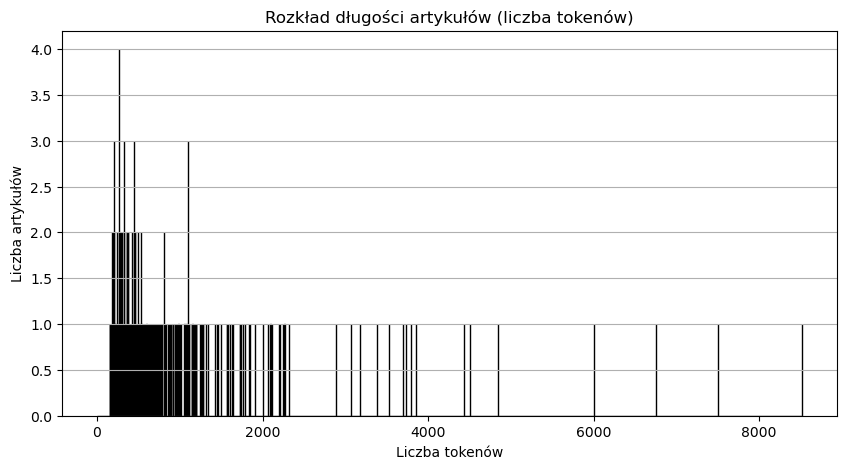

In [ ]:
#general statiscis

len_ques = [len(nlp(q)) for q in ques]

print(f"Pytania:\nIlość: {len(len_ques)}")
print(f"Średnia długość: {np.mean(len_ques):.2f}")
print(f"Mediana długości: {np.median(len_ques)}")
print(f"Min długość: {min(len_ques)}")
print(f"Maks długość: {max(len_ques)}")

plt.figure(figsize=(10, 5))
plt.hist(len_ques, bins=range(1, max(len_ques)+2), edgecolor='black')
plt.title('Rozkład długości pytań (liczba tokenów)')
plt.xlabel('Liczba tokenów')
plt.ylabel('Liczba pytań')
plt.grid(axis='y')
plt.savefig('rozkład_pytań.png', dpi=300, bbox_inches='tight')
plt.show()


len_con = [len(nlp(c)) for c in con]

print(f"Artykuły:\nIlość: {len(len_con)}")
print(f"Średnia długość: {np.mean(len_con):.2f}")
print(f"Mediana długości: {np.median(len_con)}")
print(f"Min długość: {min(len_con)}")
print(f"Maks długość: {max(len_con)}")

plt.figure(figsize=(10, 5))
plt.hist(len_con, bins=range(1, max(len_con)+2), edgecolor='black')
plt.title('Rozkład długości artykułów (liczba tokenów)')
plt.xlabel('Liczba tokenów')
plt.ylabel('Liczba artykułów')
plt.grid(axis='y')
plt.savefig('rozkład_art.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1800x300 with 0 Axes>

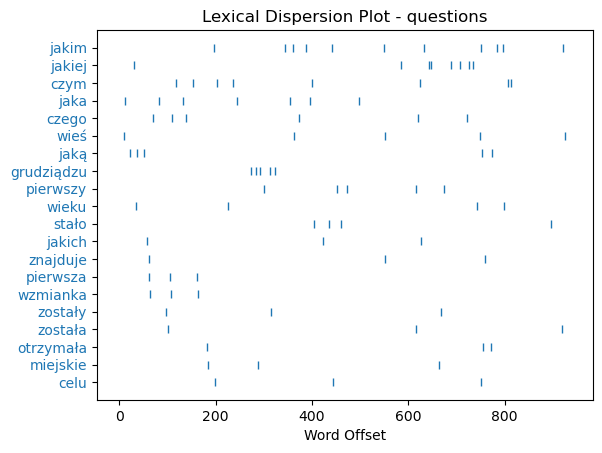

<Figure size 1800x300 with 0 Axes>

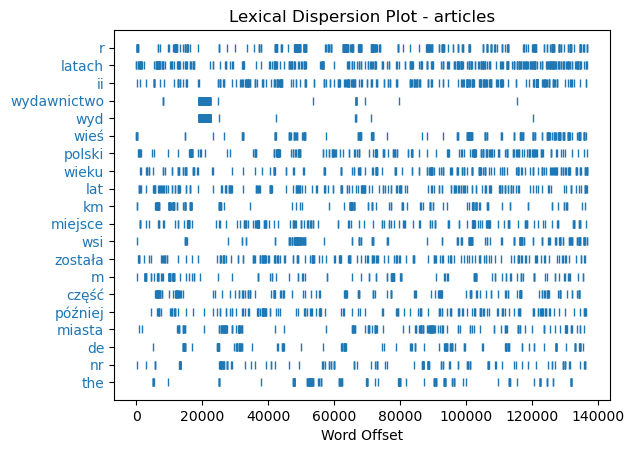

In [83]:
#dispersion plots

plt.figure(figsize=(18, 3))
targets = [word for (word, f) in fques.most_common(20)]
dispersion_plot(ques_tok, targets, ignore_case=True, title='Lexical Dispersion Plot - questions')
plt.savefig('dispersion_questions.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(18, 3))
targets = [word for (word, f) in fcon.most_common(20)]
dispersion_plot(con_tok, targets, ignore_case=True, title='Lexical Dispersion Plot - articles')
plt.savefig('dispersion_articles.png', dpi=300, bbox_inches='tight')
plt.show()

In [84]:
#analiza dyspersion plot - co to r?
nltk_text = Text(con_tok)

nltk_text.concordance("r", lines=10, width=80)

#dodatkowa analiza wskazała z r to pozostałość po dacie (np 1820 r.), myślałam nad usunięciem, 
#ale po researchu BERT może nauczyć się traktować 'r' jako wyznacznik czasowy i asocjować to z pytaniami "Kiedy ... ?"

Displaying 10 of 428 matches:
łej wskutek podziału administracyjnego r gminy wieliszew graniczą bezpośrednio 
oczymskiego serockiego sochaczewskiego r tereny znalazły zaborze pruskim xix wi
bręb województwa warszawskiego dopiero r wyodrębniony oddzielny powiat nowy dwó
szar należał schyłku diecezji płockiej r wszedł skład archidiecezji warszawskie
szedł skład archidiecezji warszawskiej r łajski weszły skład diecezji warszawsk
ych czasach postać działacza polskiego r założycieli pierwszym prezesem warszaw
wacław gąsiorowski hrabia założycielem r umiejscowionej nieopodal łajsk huty sz
zęści obecnej gminy wieliszew wrześniu r wojska hitlerowskich najeźdźców zatrzy
ch czasach została rozebrana zbudowana r szkoła miejscu znajduje obecnie skwer 
wskiego pierwszego dyrektora założonej r łajskach szkoły terenie łajsk znajduje


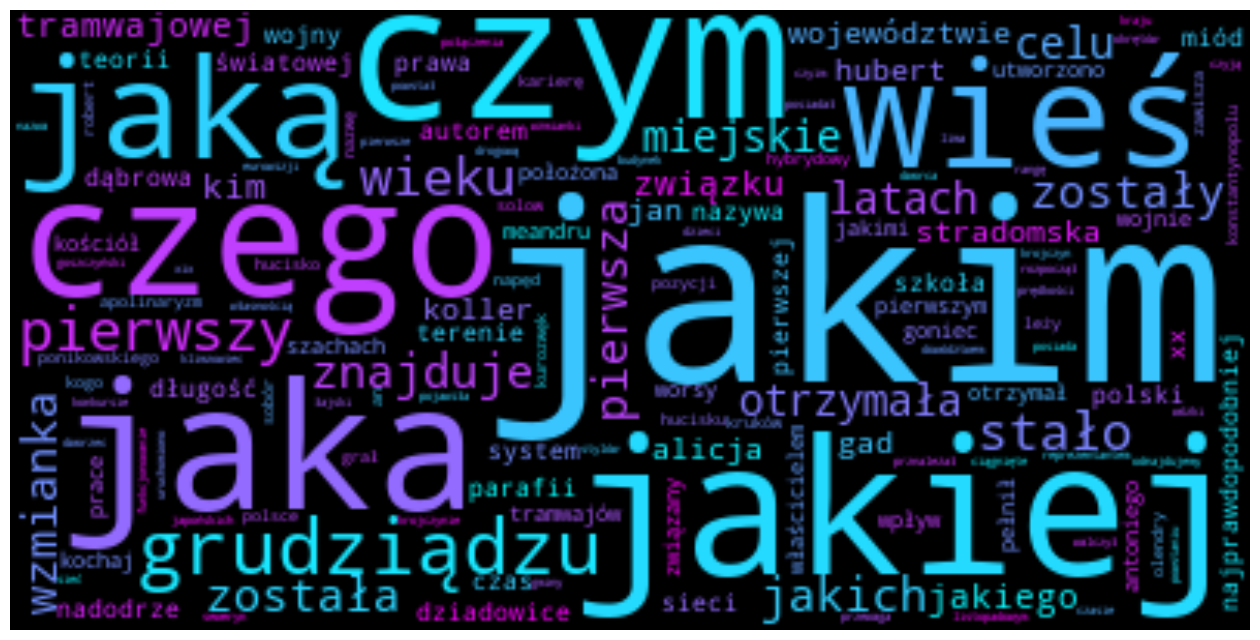

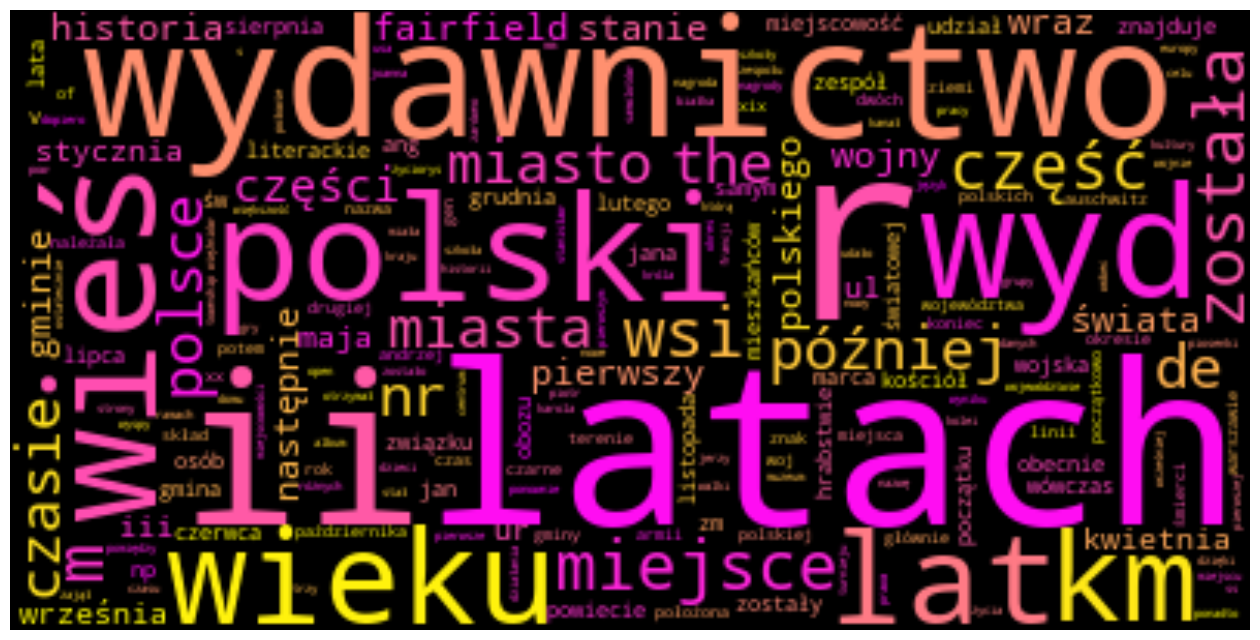

In [85]:
cloud = WordCloud(max_font_size=80,colormap="cool").generate_from_frequencies(fques)
plt.figure(figsize=(16,12)) 
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('cloud_ques.png', dpi=300, bbox_inches='tight')
plt.show()
cloud = WordCloud(max_font_size=80,colormap="spring").generate_from_frequencies(fcon)
plt.figure(figsize=(16,12)) 
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('cloud_art.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
import pickle
with open('train_sho.pkl', 'rb') as f:
    con_sho = pickle.load(f)
with open("train_med.pkl", "rb") as f:
    con_med = pickle.load(f)
with open("train_long.pkl", "rb") as f:
    con_lon = pickle.load(f)

with open('ques_sho.pkl', 'rb') as f:
    ques_sho = pickle.load(f)
with open("ques_med.pkl", "rb") as f:
    ques_med = pickle.load(f)
with open("ques_lon.pkl", "rb") as f:
    ques_lon = pickle.load(f)

with open('ans_sho.pkl', 'rb') as f:
    ans_sho = pickle.load(f)
with open("ans_med.pkl", "rb") as f:
    ans_med = pickle.load(f)
with open("ans_lon.pkl", "rb") as f:
    ans_lon = pickle.load(f)